In [1]:
# Set up the file path
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(parent_dir)
print('Parent directory set to:', parent_dir)
target_directory = '/local0/home/mfilo/git/CRN-GenerativeAI/apps_results_HF_REINFORCE/logic_4inputs_1output_6species_6rxns/'
sys.path.append(parent_dir)
print('Working directory set to:', parent_dir)
print('Target directory set to:', target_directory)

Parent directory set to: /local0/home/mfilo/git/CRN-GenerativeAI
Working directory set to: /local0/home/mfilo/git/CRN-GenerativeAI
Target directory set to: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_HF_REINFORCE/logic_4inputs_1output_6species_6rxns/


In [2]:
# Import general packages
from openpyxl import Workbook, load_workbook
from openpyxl.utils import get_column_letter
from datetime import datetime
import torch
from matplotlib import pyplot as plt
from pytorch_lightning.loggers import CometLogger
import numpy as np
from itertools import product
from tqdm import tqdm

# Import Agent-Environment packages
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.parallel_environments import ParallelEnvironments
from RL4CRN.environments.serial_environments import SerialEnvironments
from RL4CRN.agents.reinforce_agent import REINFORCEAgent
from RL4CRN.policies.add_reaction_by_ordered_index import AddReactionByOrderedIndex
from RL4CRN.policies.add_reaction_by_index import AddReactionByIndex

# Import Interface packages
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_hill_production_library

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error

# Import visualization packages
from RL4CRN.utils.visualizations import plot_truth_table

In [3]:
# Filename for loading the agent checkpoint
load_path = os.path.join(target_directory, 'models')
print('Loading models from:', load_path)

# locate all files corresponding to *.pth in the subdirectory of load path
input_paths = []
for file in os.listdir(load_path):
    if file.endswith('.pth') and not file.startswith('generated_'):
        input_paths.append(os.path.join(load_path, file))

save_flag = True                # Save the results of the obtained IOCRNs

# No logger needed
logger = None

Loading models from: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_HF_REINFORCE/logic_4inputs_1output_6species_6rxns/models


In [4]:
# Construct the template CRN
productions = []
dilutions = []
n_inputs = 4
species_labels = [f'X_{i+1}' for i in range(n_inputs)] 
for i,s in enumerate(species_labels):
    productions.append(MassAction(reactant_labels=[], product_labels=[s], input_channels=[f'u_{i+1}'], params=[1.], params_controllability=[True]))
    dilutions.append(MassAction(reactant_labels=[s], product_labels=[], input_channels=[None], params=[1.], params_controllability=[False]))
species_labels.append('X_5')
species_labels.append('OUT') # add output species label
dilutions.append(MassAction(reactant_labels=['X_5'], product_labels=[], input_channels=[None], params=[1.], params_controllability=[True]))
dilutions.append(MassAction(reactant_labels=['OUT'], product_labels=[], input_channels=[None], params=[1.], params_controllability=[True]))
crn_template = IOCRN(productions + dilutions, output_labels=['OUT'])
crn_template.compile()
p = crn_template.num_inputs # Number of inputs of the IOCRNs
crn_template.atol = 1e-6
crn_template.rtol = 1e-6
print("Template CRN:")
print(crn_template)

# Construct the library of possible reactions
library = construct_hill_production_library(species_labels=species_labels, max_product_order=1, max_num_regulators=2)
library.add_reactions(productions+dilutions) # add the production reactions to the library
zero_reaction = MassAction(reactant_labels=[], product_labels=[], input_channels=[None], params=[1.], params_controllability=[False]) # define the zero reaction (∅ → ∅)
library.add_reactions(zero_reaction) # add the zero reaction to the library
library.prepare_lookup_tables()
crn_template.set_library_context(library)
M = len(library.reactions) # Number of possible reactions
K = library.get_num_parameters() # Total number of parameters in all the reactions of the library
print("Library of possible reactions:")
print(library)
print("------------------------------------------------")

Template CRN:
Inputs: ['u_1', 'u_2', 'u_3', 'u_4'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3', 'X_4', 'X_5'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
∅ ----> X_4;  [MAK(1.0, u_4)]
X_1 ----> ∅;  [MAK(1.0)]
X_2 ----> ∅;  [MAK(1.0)]
X_3 ----> ∅;  [MAK(1.0)]
X_4 ----> ∅;  [MAK(1.0)]
X_5 ----> ∅;  [MAK(1.0)]
OUT ----> ∅;  [MAK(1.0)]
Library of possible reactions:
Number of reactions: 443
R0: ∅ ----> X_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = ;    (Kr, nr) = X_1(None, 1))]
R1: ∅ ----> X_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = ;    (Kr, nr) = X_2(None, 1))]
R2: ∅ ----> X_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = ;    (Kr, nr) = X_3(None, 1))]
R3: ∅ ----> X_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = ;    (Kr, nr) = X_4(None, 1))]
R4: ∅ ----> X_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = ;    (Kr, nr) = X_5(None, 1))]
R5: ∅ ----> X_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = ;    (Kr, n

In [5]:
# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Number of CPUs available: {os.cpu_count()}') 

Using device: cuda
Number of CPUs available: 128


In [6]:
# Hyperparameters
max_added_reactions = 6                             # Maximum number of reactions
N_CPUs = os.cpu_count()                             # Number of CPUs          
N = 10*N_CPUs                                       # Number of samples (batch size)    
width = 1024                                        # Width of the neural networks  
depth = 5                                           # Depth of the neural networks 
deep_layer_size = 1024*10                           # Size of the deep layer encoding the CRNs
allow_input_influence = False                       # Allow input influence in the policy
learning_rate = 1e-3                                # Learning rate for the optimizer 
hall_of_fame_size = 30                              # Size of the hall of fame  
entropy_scheduler = {                                   # Entropy scheduler parameters 
    'entropy_weight': 1e-3 ,                            # Global entropy weight
    'entropy_weight_structure_head': 5.0,               # Entropy weight for the structure head
    'entropy_weight_continuous_head': 0.5,              # Entropy weight for the continuous parameters head
    'topk_entropy_weight': 1.0,                         # Entropy weight for the top-k actions
    'remainder_entropy_weight': 1.0,                    # Entropy weight for the remainder actions
    'entropy_update_coefficient': 1,                    # Entropy update coefficient (multiplicative)
    'entropy_schedule': 1000,                           # Entropy schedule (in epochs) 
    'minimum_entropy_weight': 0.0                       # Minimum entropy weight
}
structure_head_temperature = {
    'target_entropy_ratio_to_max': np.log(5)/np.log(M), 
    'initial_temperature': 1.0, 
    'rate': 0.0, 
    'current_temperature': 1.0}
risk_scheduler = {                                      # Risk scheduler parameters
    'risk': 0.9,                                        # Percentage of worst samples to disregard when computing the reward
    'risk_update': 0.0,                                 # Risk update coefficient (additive)
    'max_risk': 1.0,                                    # Maximum risk
    'risk_schedule': 1000                               # Risk schedule (in epochs)
}
epoch_num = 500                                         # Number of epochs for training
render_schedule = 10                                    # Render every # of epochs
render_mode = {                                         # Mode of the experiment
    'style': 'logger', 
    'task': 'transients + logic', 
    'format': 'image',
    'topology': True,
    'bounds': [2.5]
}
render_n_best = 10                                      # Number of best CRNs to plot responses for
render_disregard_percentage = 0.99                      # Percentage of worst CRNs to disregard in the responses plotting
sil_settings = {
    'sil_loss_weight': 1.0,
}

# Parameter distribution for the reactions added by the agent
continuous_distribution = {"type": 'lognormal_independent'}

# Stopping and zero reaction flags
stop_flag = False                                       # Whether to stop adding reactions when the “zero reaction” is selected (only relevant if zero_reaction_idx is provided)
allow_repeated_zero_reactions = True                    # Whether to allow repeated selection of the “zero reaction”

# Time horizon for the simulation
t_f = 100                                               # Final time for the simulation
N_t = 1000                                              # Number of time steps
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs: all combination of inputs between 0 and 1 
nums = [0., 1.]
u_list = [np.array(u) for u in product(*[nums for _ in range(n_inputs)])] # list of input combinations, each input is a numpy array of shape (p,)

# Define the logic function
logic_target = lambda u : (u[0] and u[1]) or (u[1] and u[2]) or (u[2] and u[3])  # target logic function

# Construct the reference setpoints
r_list = [np.array([float(logic_target(u))]) for u in u_list]  # list of reference outputs, each output is a numpy array of shape (q,)

# Construct the IOCRN initial conditions
ic = IC(names=species_labels, values=[[0.01 for _ in species_labels]])

# Construct the weights for the performance metric
# w = np.ones(N_t)
# w[(len(w)//5)*4:] = w[(len(w)//5)*4:]*2
# w[:(len(w)//5)] = w[:(len(w)//5)]*0.25
# w = w[np.newaxis, :]
w = np.zeros((1, N_t))
w[:, -1] = 1.0 * N_t

# Construct the compute reward routine
def compute_reward(state):
    x0_list = ic.get_ic(state)
    return dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)

In [7]:
# Construct parallel environments
crn_0 = crn_template.clone()
mult_env = ParallelEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, N_CPUs=N_CPUs, logger=logger)
# mult_env = SerialEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, logger=logger)

In [8]:
# Construct the policy
encoder_attributes = {"hidden_size": width, "num_layers": depth}
structure_head_attributes = {"hidden_size": width, "num_layers": depth}
rate_head_attributes = {"hidden_size": width, "num_layers": depth}
input_influence_head_attributes = {"hidden_size": width, "num_layers": depth}
masks = {"continuous": library.get_parameter_mask(mode="continuous"), "discrete": library.get_parameter_mask(mode="discrete"), "logit": library.get_logit_mask()}
entropy_weights_per_head = {'structure': entropy_scheduler['entropy_weight_structure_head'], 'continuous': entropy_scheduler['entropy_weight_continuous_head'], 'discrete': 0.0, 'input_influence': 0.0} 
zero_reaction_idx = library.find_zero_reaction() if allow_repeated_zero_reactions else None 
policy = AddReactionByIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, allow_input_influence=allow_input_influence, masks=masks, zero_reaction_idx=zero_reaction_idx, stop_flag=stop_flag, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head)

# Construct the agent
agent = REINFORCEAgent(policy, allow_input_influence=allow_input_influence, logger=logger, learning_rate=learning_rate, entropy_scheduler=entropy_scheduler, risk_scheduler=risk_scheduler, sil_settings=sil_settings, device=device)

In [9]:
# Construct the interfaces
observer = ExplicitObserver(reaction_library=library, allow_input_observation=allow_input_influence)
tensorizer = ExplicitTensorizer(device=device)
actuator = LibraryActuator(reaction_library=library)
stepper = IOCRNStepper()

In [10]:
# Test the model
from tqdm import tqdm
sorted_crns_rewards_list = []
for p in tqdm(input_paths):
    agent.policy.load_state_dict(torch.load(p, map_location=device))

    agent.policy.eval()
    mult_env.reset()
    for j in range(max_added_reactions):
        observations = mult_env.observe(observer, tensorizer)
        actions, raw_actions = agent.act(observations, actuator)
        out = mult_env.step(actions, stepper, raw_actions=raw_actions)
    rewards = mult_env.get_reward(compute_reward)

    # Gather the CRNs from the environments
    crns = mult_env.gather()

    # Sort the CRNs by rewards
    sorted_crns_rewards = sorted(zip(crns, rewards), key=lambda x: x[1])
    sorted_crns_rewards_list.append(sorted_crns_rewards)

100%|██████████| 1/1 [01:29<00:00, 89.96s/it]


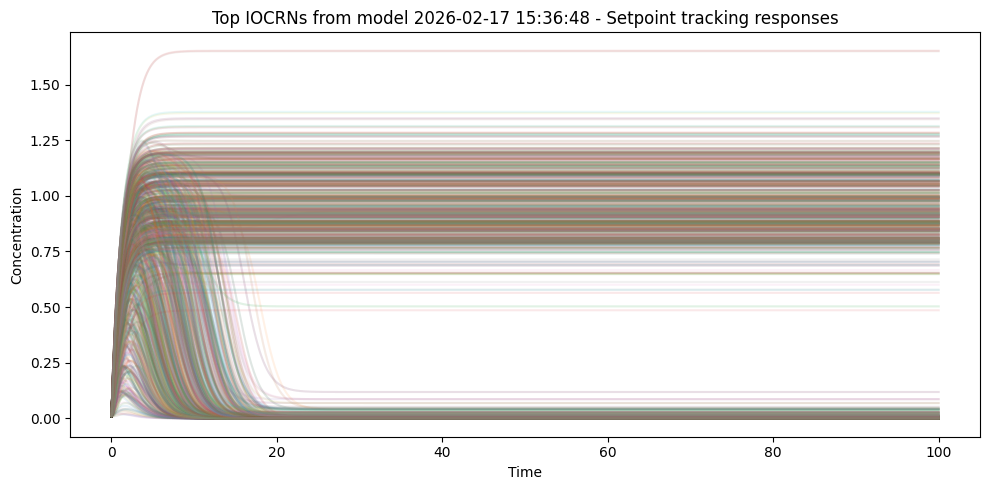

In [11]:
# Plot the results
for  j, sorted_crns_rewards in enumerate(sorted_crns_rewards_list):
    n_plot = 100
    ax = None
    for i in range(n_plot):
        x0_list = ic.get_ic(sorted_crns_rewards[i][0])
        time_horizon, x_list, y_list, last_task_info = sorted_crns_rewards[i][0].transient_response(u_list, x0_list, time_horizon)
        fig, ax = sorted_crns_rewards[i][0].plot_transient_response(axes=ax)
        model_name = os.path.basename(input_paths[j]).replace('.pth','')
        ax[0].set_title(f'Top IOCRNs from model {model_name} - Setpoint tracking responses')
        # print(f"IOCRN {i}, Reward: {sorted_crns_rewards[i][1]}")
        # print(sorted_crns_rewards[i][0])

In [12]:
if save_flag:
    for j, sorted_crns_rewards in enumerate(sorted_crns_rewards_list):
        load_filename = os.path.basename(input_paths[j]).replace('.pth','')
        output_path = os.path.join(target_directory, 'models', 'generated_' + load_filename + '.pth')
        print('Saving generated CRNs to file:','generated_' + output_path + '.pth')
        sorted_crns = [crn for crn, _ in sorted_crns_rewards]
        torch.save(sorted_crns, output_path)

Saving generated CRNs to file: generated_/local0/home/mfilo/git/CRN-GenerativeAI/apps_results_HF_REINFORCE/logic_4inputs_1output_6species_6rxns/models/generated_2026-02-17 15:36:48.pth.pth
